In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms.v2 as transforms
import matplotlib.pyplot as plt

# 데이터 변환 및 로드
transform = transforms.Compose([
    transforms.ToTensor()
])

# 학습 데이터셋 (일부만 사용하여 오버피팅 유도)
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
subset_indices = torch.arange(0, 2000)  # 학습 데이터 2000개만 사용
train_subset = torch.utils.data.Subset(train_dataset, subset_indices)
train_loader = torch.utils.data.DataLoader(train_subset, batch_size=64, shuffle=True)

# 테스트 데이터셋
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

c:\sk-encoa\dl_workspace\.venv\Lib\site-packages\torchvision\transforms\v2\_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [11]:
class OverfittingNet(nn.Module):
    def __init__(self):
        super(OverfittingNet, self).__init__()
        self.flatten = nn.Flatten()
        self.layer1 = nn.Linear(1*28*28, 512)
        self.relu1 = nn.ReLU()
        self.layer2 = nn.Linear(512, 256)
        self.relu2 = nn.ReLU()
        self.layer3 = nn.Linear(256, 128)
        self.relu3 = nn.ReLU()
        self.layer4 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu1(self.layer1(x))
        x = self.relu2(self.layer2(x))
        x = self.relu3(self.layer3(x))
        x = self.layer4(x)
        return x

# 모델, 손실 함수, 옵티마이저 정의
model = OverfittingNet()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [12]:
# 학습 함수
def train(model, loader, optimizer, criterion):
    model.train()
    running_loss = 0.0
    for inputs, targets in loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    return running_loss / len(loader)

# 평가 함수
def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, targets in loader:
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += targets.size(0)
            correct += (predicted == targets).sum().item()
    accuracy = 100 * correct / total
    return running_loss / len(loader), accuracy

Epoch [1/100] - Train Loss: 1.0920, Test Loss: 0.5726, Accuracy: 81.58%
Epoch [2/100] - Train Loss: 0.3886, Test Loss: 0.5481, Accuracy: 84.76%
Epoch [3/100] - Train Loss: 0.3016, Test Loss: 0.4811, Accuracy: 86.54%
Epoch [4/100] - Train Loss: 0.2301, Test Loss: 0.4172, Accuracy: 88.78%
Epoch [5/100] - Train Loss: 0.1610, Test Loss: 0.4355, Accuracy: 89.27%
Epoch [6/100] - Train Loss: 0.1118, Test Loss: 0.4217, Accuracy: 90.63%
Epoch [7/100] - Train Loss: 0.0854, Test Loss: 0.5570, Accuracy: 89.71%
Epoch [8/100] - Train Loss: 0.0999, Test Loss: 0.5846, Accuracy: 88.78%
Epoch [9/100] - Train Loss: 0.1113, Test Loss: 0.5869, Accuracy: 87.85%
Epoch [10/100] - Train Loss: 0.0715, Test Loss: 0.5729, Accuracy: 89.40%
Epoch [11/100] - Train Loss: 0.1338, Test Loss: 0.6439, Accuracy: 87.48%
Epoch [12/100] - Train Loss: 0.1794, Test Loss: 0.7132, Accuracy: 87.35%
Epoch [13/100] - Train Loss: 0.1382, Test Loss: 0.9044, Accuracy: 86.71%
Epoch [14/100] - Train Loss: 0.1725, Test Loss: 0.4782, Accu

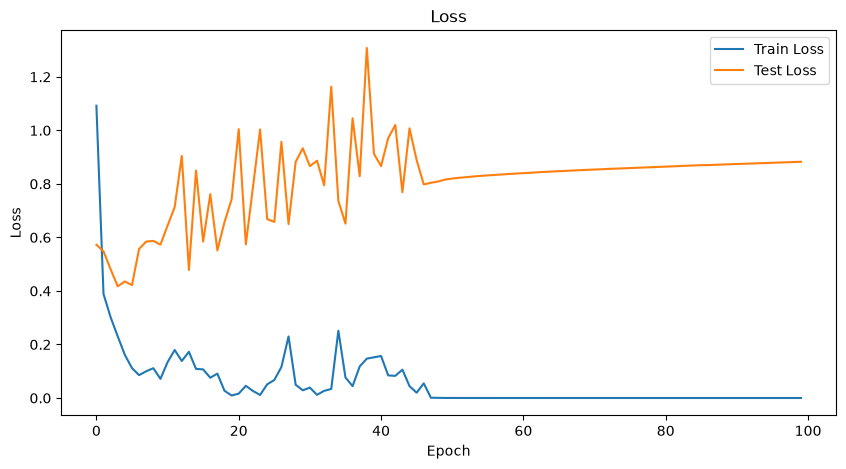

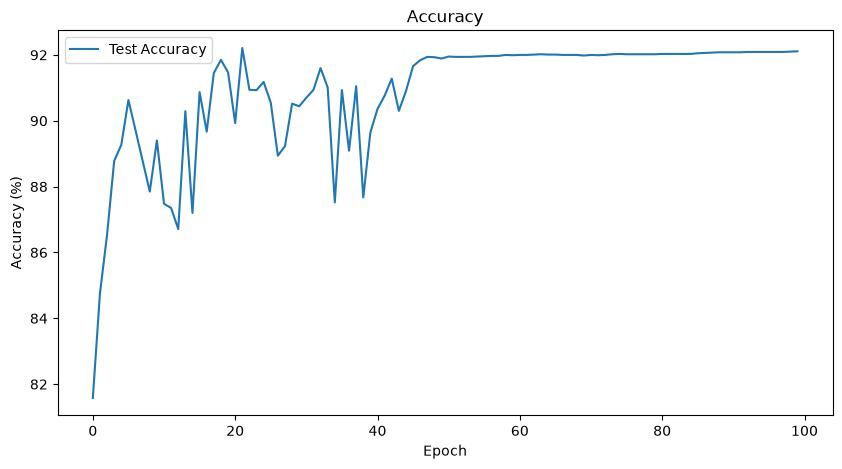

In [13]:
# 학습 및 평가 기록을 저장할 리스트
train_losses = []
test_losses = []
test_accuracies = []

num_epochs = 100
for epoch in range(num_epochs):
    train_loss = train(model, train_loader, optimizer, criterion)
    test_loss, test_accuracy = evaluate(model, test_loader, criterion)

    train_losses.append(train_loss)
    test_losses.append(test_loss)
    test_accuracies.append(test_accuracy)

    print(f'Epoch [{epoch+1}/{num_epochs}] - Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}, Accuracy: {test_accuracy:.2f}%')

# 손실 곡선 시각화
plt.figure(figsize=(10,5))
plt.title('Loss')
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# 정확도 곡선 시각화
plt.figure(figsize=(10,5))
plt.title('Accuracy')
plt.plot(test_accuracies, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.show()

In [7]:
# 데이터 변환에 데이터 증강 기법 추가
transform_augmented = transforms.Compose([
    transforms.RandomRotation(10),
    transforms.ToImage(),
    transforms.ToDtype(torch.float32, scale=True)
])

# 데이터셋 및 로더 재정의
train_dataset_augmented = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform_augmented)
train_subset_augmented = torch.utils.data.Subset(train_dataset_augmented, subset_indices)
train_loader_augmented = torch.utils.data.DataLoader(train_subset_augmented, batch_size=64, shuffle=True)